In [1]:
%matplotlib widget 
# Uncomment for interactive plots when running the notebook!

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from time import perf_counter

import import_ipynb

import PyPO
from PyPO.System import System
from PyPO.Enums import Projections, Objects, Units, Scales, FieldComponents, CurrentComponents

In [2]:
# This code allows us to display global variables within markdown output, by overriding the %%markdown magic
from IPython.display import Markdown
from IPython.core.magic import register_cell_magic

@register_cell_magic
def markdown(line, cell):
    return Markdown(cell.format(**globals()))

# Import the system from `sma_beamwaveguide_setup`

2026-03-17 17:06:28 - WARNING - System override set to True. 
Primary Focal Length (F_p) : 2.520 m
Primary Rim Height (h_p): 0.893 m
Angle of edge ray (alpha) :61.52543906847784°
Vertical distance from prime focus to secondary edge plane (z_sedge1): 0.094917 m
Distance from prime focus to secondary edge plane (r_sedge1): 0.094916667 m
Angle of edge ray from Cassegrain focus to secondary edge (thetae) 2.0462388063868757°
Distance from Cassegrain focus to secondary edge (r_sedge2) 4.901135272577161 m
Subreflector eccentricity (e_s): 1.0618612323260763

Subreflector conic constant (k): -1.1275492767170534
Subreflector distance to vertex (a_s) : 2.351025969621911 m
Subreflector distance to focus (c_s): 2.496463333333331 m
Subreflector distance between foci (2 c_s) : 4.992926666666662 m
Ratio between distance between foci and Primary focal length (2 c_s/F_p) : 1.981320105820104
Subreflector (b_s) : 0.8396463927398957 m

Subreflector radius of curvature on axis (R_s): 0.28240193053417684 m
S

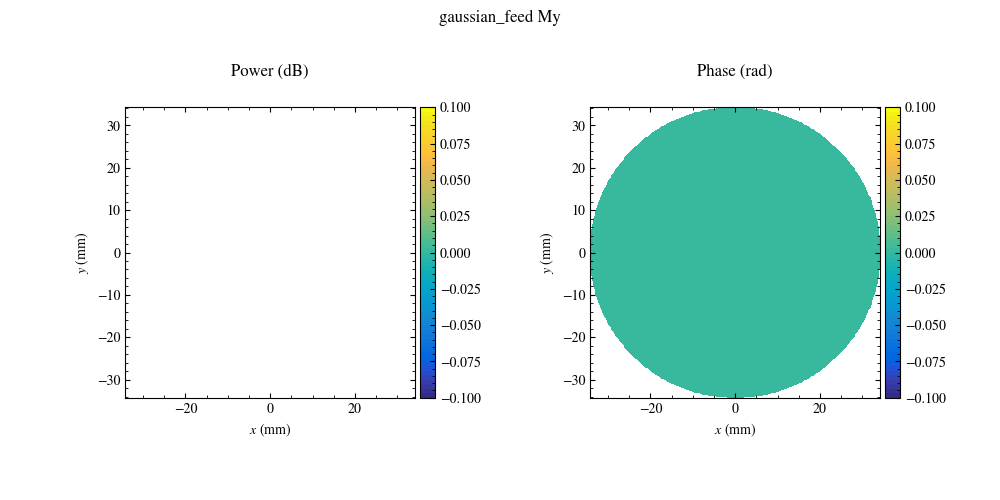

820.408910848911
Estimated Grid size : (341, 820)
Maximum Grid size   : (269, 1691)
2026-03-17 17:06:28 - INFO - Added hyperboloid secondary to system. 
2754.444791392808
Estimated Grid size : (1147, 2754)
Maximum Grid size   : (4615, 28999)
2026-03-17 17:06:28 - INFO - Added paraboloid primary to system. 
2026-03-17 17:06:28 - INFO - Added plane sec_plane to system. 
2026-03-17 17:06:28 - INFO - Translated element sec_plane by ('0.000e+00', '0.000e+00', '2.425e+03') millimeters. 
2026-03-17 17:06:28 - INFO - Added plane farfield_plane to system. 
Radius of feed image: a_sr = 228.6 mm
Beam radius: w_sr = 147.1 mm
Magnification: m = 0.2057
Distance from virtual feed to M5 : L_1 = 2941.0 mm
Distance from M4 to secondary : L_4 = 4901.1 mm
Distance from intermediate image to M5 : L_2 = 964.9 mm
Distance from intermediate image to M4 : L_3 = 330.8 mm
z position of intermediate image : z_i = 3125.9 mm
beam radius of intermediate image : w_i = 9.9245 mm
focal length of M5 : f_M5 = 726.529 mm


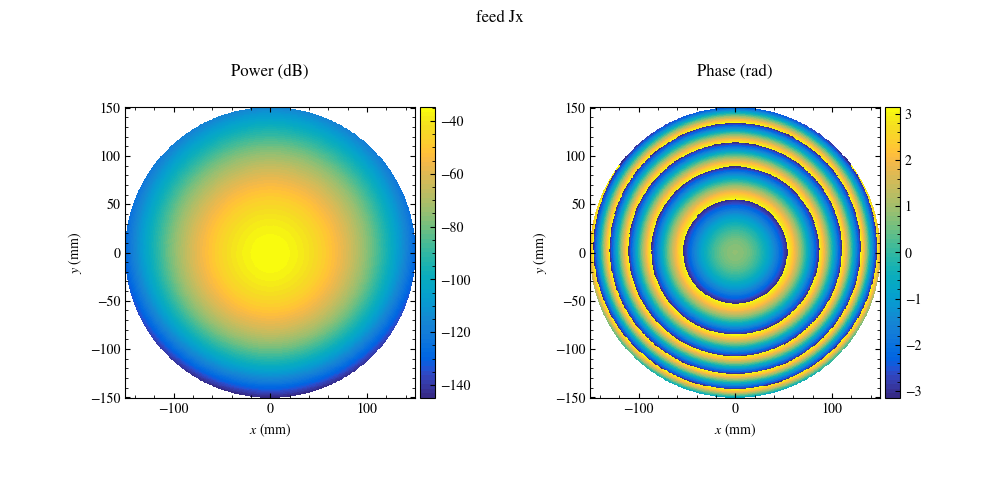

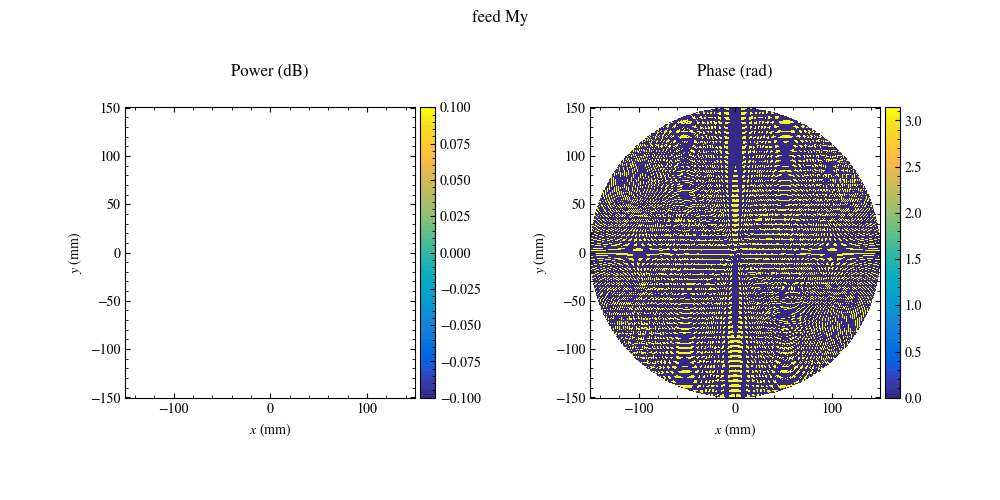

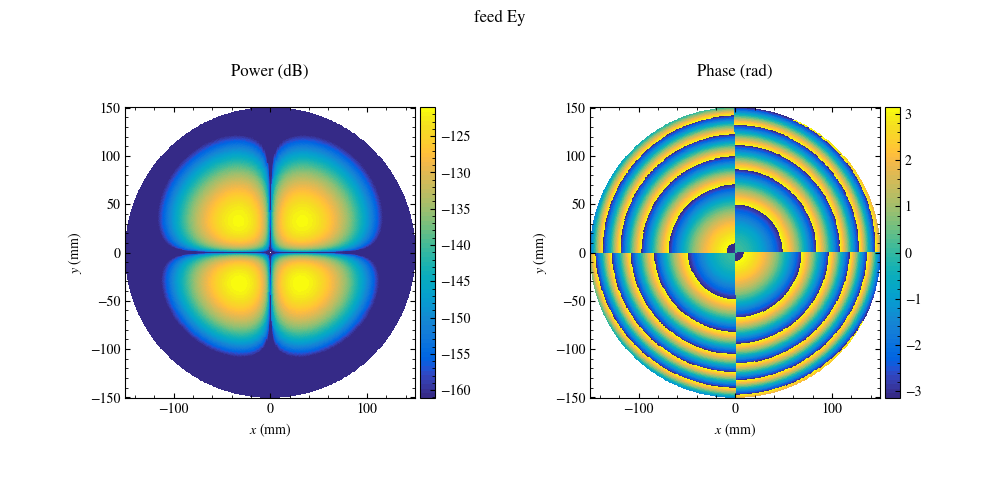

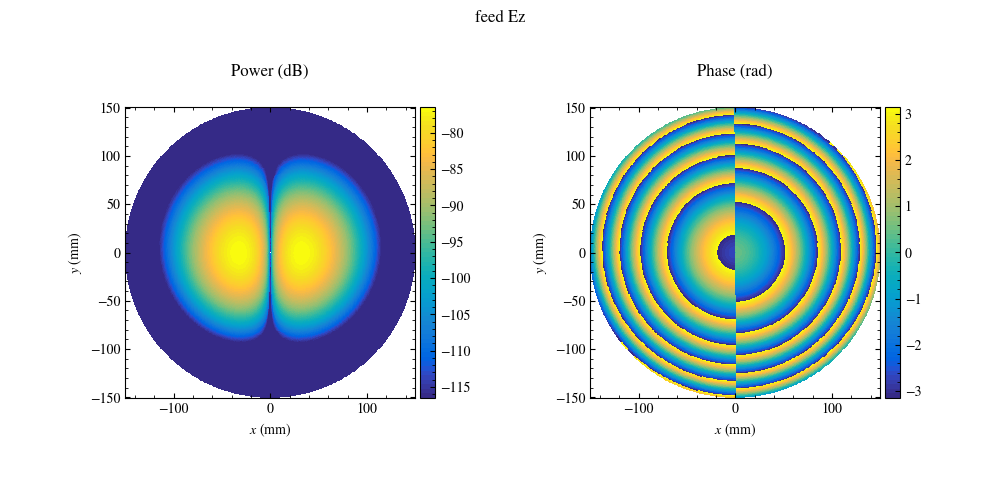

2026-03-17 17:06:30 - INFO - Translated element flat_M6 by ('0.000e+00', '0.000e+00', '-4.172e+03') millimeters. 
2026-03-17 17:06:31 - INFO - Rotated element flat_M6 by ('-9.000e+01', '1.800e+02', '0.000e+00') degrees around ('0.000e+00', '0.000e+00', '-2.041e+03'). 
2026-03-17 17:06:31 - INFO - Rotated element flat_M6 by ('0.000e+00', '0.000e+00', '1.302e+02') degrees around ('1.192e-11', '-4.351e+02', '-2.041e+03'). 
2026-03-17 17:06:32 - INFO - Rotated element flat_M6 by ('0.000e+00', '0.000e+00', '2.298e+02') degrees around ('9.896e+02', '4.012e+02', '-2.041e+03'). 
Nominal M5-M6 distance: 400.00 mm
Actual M5-M6 distance: 398.00 mm


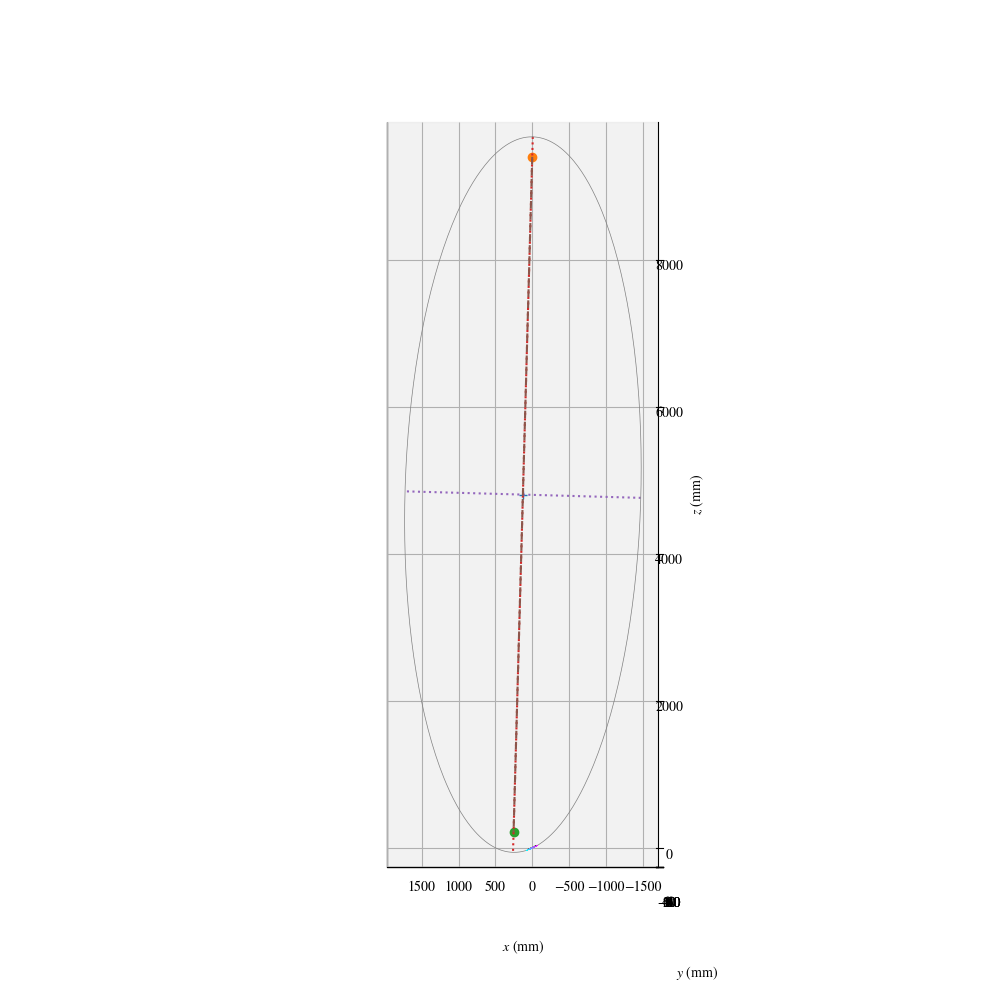

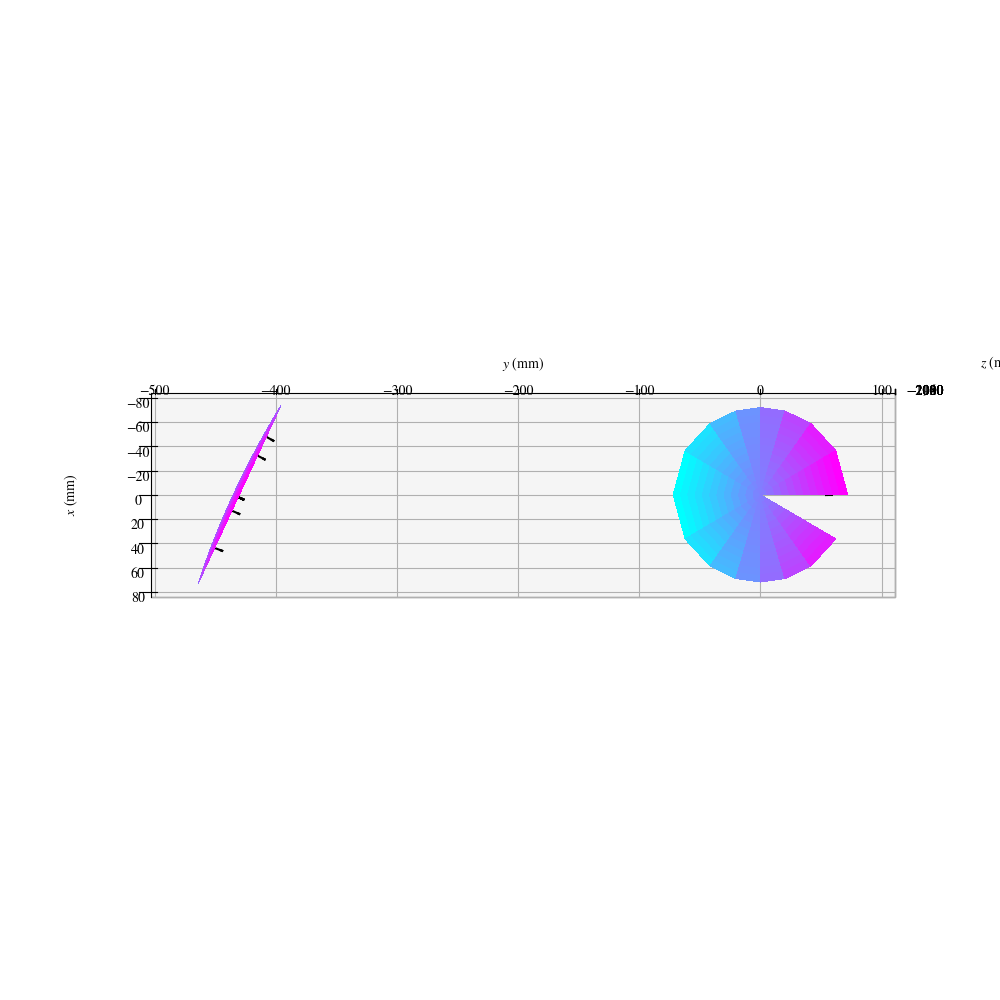

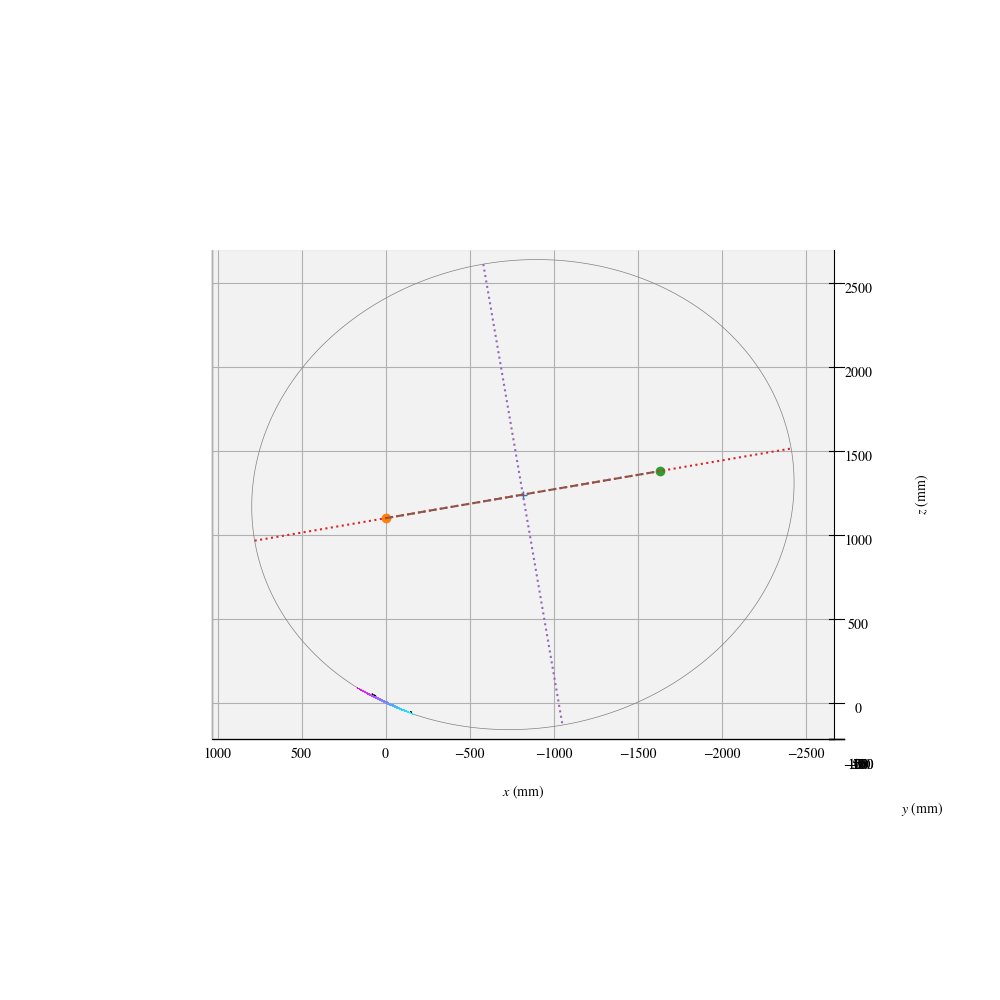

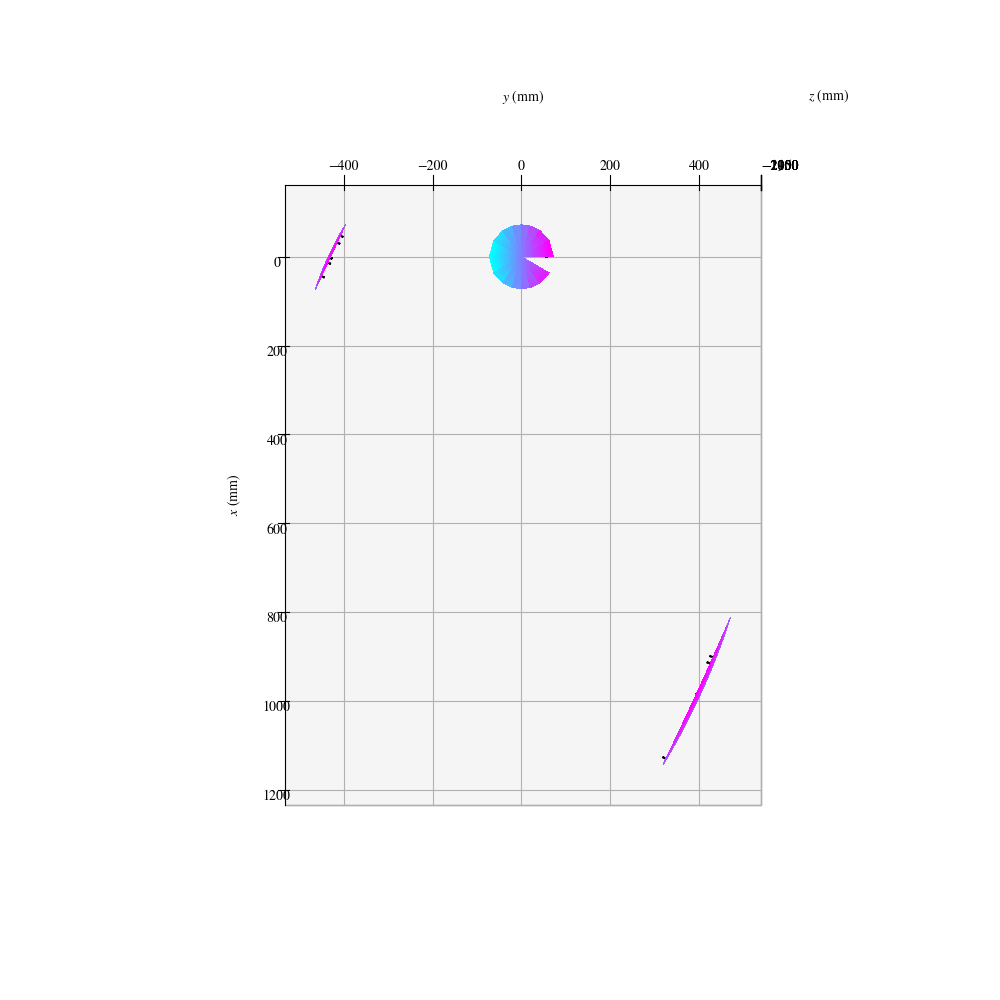

In [3]:
from sma_beamwaveguide_setup import s, M4M5_bendangle
bend_angle=np.deg2rad(M4M5_bendangle)

# Calculation

Now that we have set up the system correctly, we can start running Physical optics to calculate the performance of the beam waveguide

In [4]:
from time import perf_counter

step_times = []

In [5]:
# Set up our choice of calculation method.
method = 'GPU'
if method == 'CPU':
    nThreads = 24
else:
    nThreads = 256
mode = 'JMEH'

epsilon = 1.0

## VF to M6 Physical Optics

In [6]:
# vf_to_M6_PO = {
#     "t_name"    : "flat_M6",
#     "s_current" : "feed",
#     "mode"      : "JMEH",
#     "name_JM"   : "M6_JM",
#     "name_EH"   : "M6_EH",
#     "device"    : method,
#     "nThreads"  : nThreads
# }

# start = perf_counter()
# s.runPO(vf_to_M6_PO)
# step_times.append(perf_counter()-start)

In [7]:
s.fields

{'gaussian_feed': <PyPO.PyPOTypes.fields at 0x736c46364980>,
 'feed': <PyPO.PyPOTypes.fields at 0x736c462ae470>}

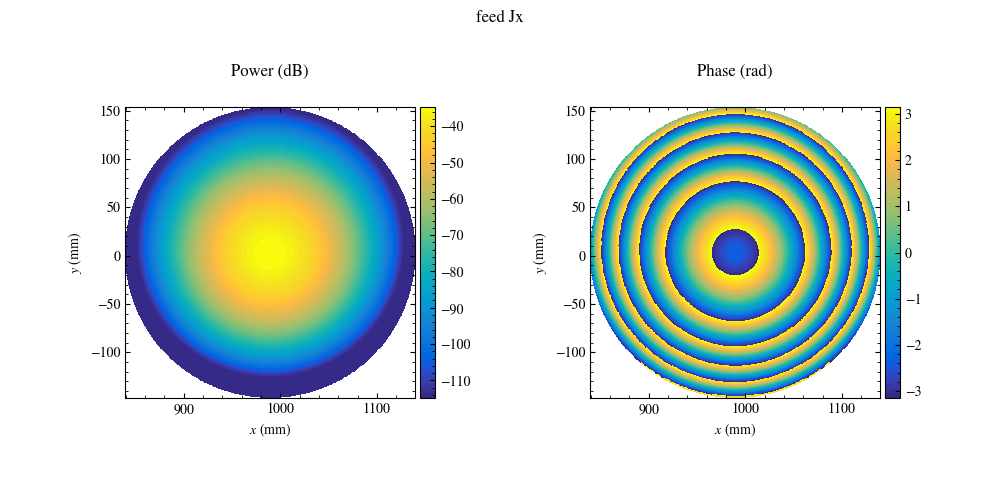

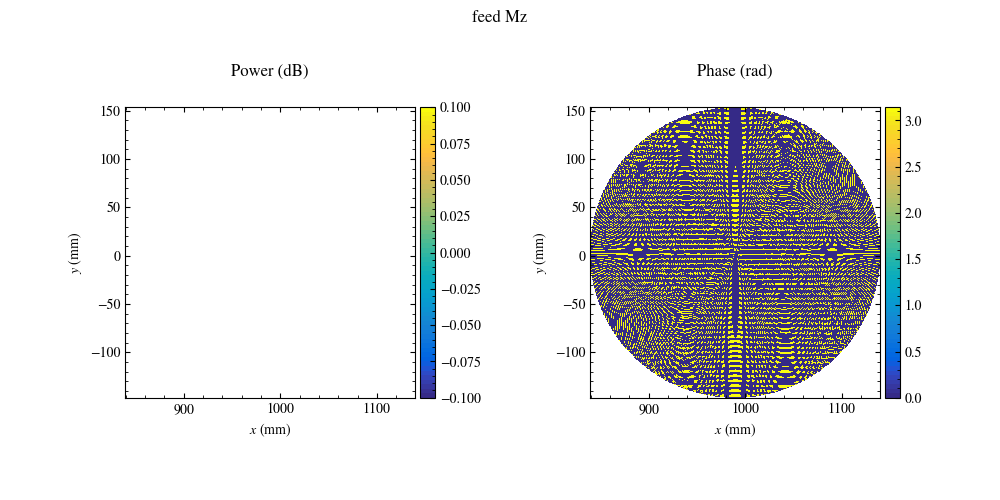

In [28]:
phasevect = np.array((0, 1, 0))

s.plotBeam2D("feed", CurrentComponents.Jx, vmin=-80, norm=False, \
    contour="feed", contour_comp=FieldComponents.Ex, levels=[-12.7,-10.0, 20*np.log10(np.exp(-1))], \
    correct_phase=[0,0,-1])

s.plotBeam2D("feed", CurrentComponents.Mz, vmin=-80, norm=False, project=Projections.xy, \
    contour="feed", contour_comp=CurrentComponents.Mz, levels=[-12.7,-10.0, 20*np.log10(np.exp(-1))], \
    correct_phase=[0,0,-1])

## M6 to M5 Physical Optics

In [9]:
M6_to_M5_PO = {
    "t_name"    : "quadric_M5",
    "s_current" : "feed",
    "mode"      : "JMEH",
    "name_JM"   : "M5_JM",
    "name_EH"   : "M5_EH",
    "device"    : method,
    "nThreads"  : nThreads
}


In [10]:
start = perf_counter()
s.runPO(M6_to_M5_PO)
step_times.append(perf_counter()-start)

2026-03-17 17:06:36 - WORK - *** Starting PO propagation *** 
2026-03-17 17:06:36 - WORK - Propagating feed on flat_M6 to quadric_M5, propagation mode: JMEH. 
2026-03-17 17:06:36 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-17 17:06:36 - WORK - ... Calculating ... 
2026-03-17 17:06:36 - WORK - *** Finished: 0.617 seconds *** 


In [11]:
phasevect = np.array((np.sin(2*bend_angle), np.cos(2*bend_angle), 0))

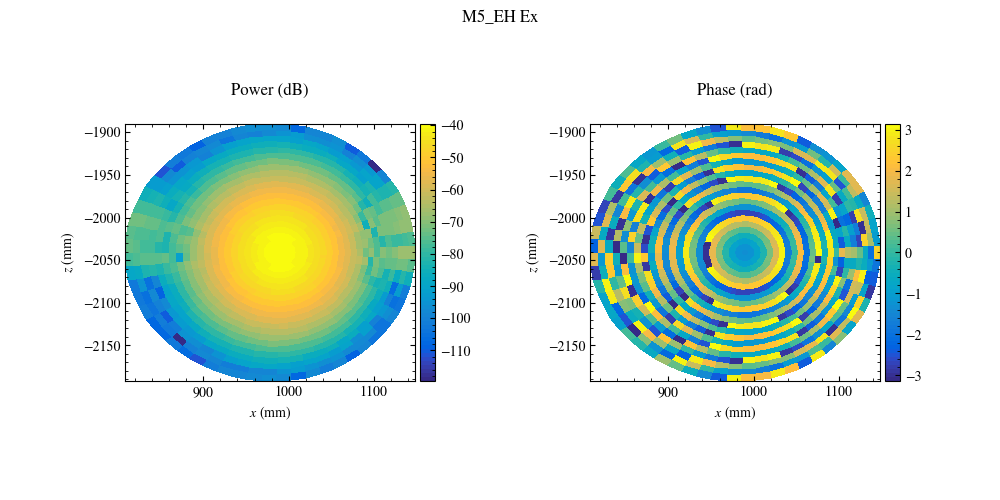

In [12]:
fig, ax = s.plotBeam2D("M5_EH", FieldComponents.Ex, project=Projections.xz, vmin = -80, norm=False, \
                        contour="M5_EH", contour_comp=FieldComponents.Ex, levels=[-12.7, 20*np.log10(np.exp(-1))], \
                        correct_phase=phasevect, ret=True)

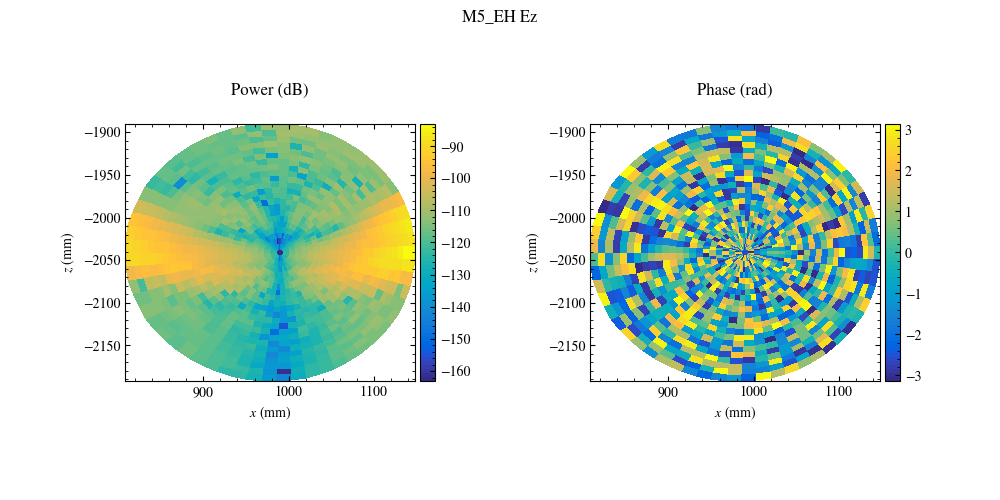

In [30]:
fig, ax = s.plotBeam2D("M5_EH", FieldComponents.Ez, project=Projections.xz, vmin = -80, norm=False, \
                        contour="M5_EH", contour_comp=FieldComponents.Ez, levels=[-12.7, 20*np.log10(np.exp(-1))], \
                        correct_phase=phasevect, ret=True)

## M5 to M4 Physical Optics

In [15]:
M5_to_M4_PO = {
    "t_name"    : "quadric_M4",
    "s_current" : "M5_JM",
    "mode"      : "JMEH",
    "name_JM"   : "M4_JM",
    "name_EH"   : "M4_EH",
    "device"    : method,
    "nThreads"  : nThreads
}

start = perf_counter()
s.runPO(M5_to_M4_PO)
step_times.append(perf_counter()-start)

2026-03-17 17:06:38 - WORK - *** Starting PO propagation *** 
2026-03-17 17:06:38 - WORK - Propagating M5_JM on quadric_M5 to quadric_M4, propagation mode: JMEH. 
2026-03-17 17:06:38 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-17 17:06:38 - WORK - ... Calculating ... 
2026-03-17 17:06:38 - WORK - *** Finished: 0.158 seconds *** 


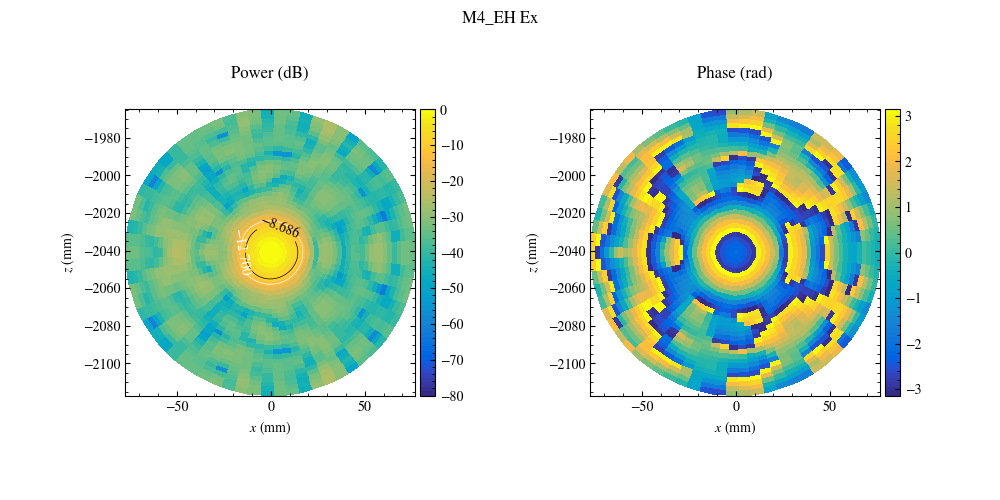

In [16]:
phasevect = np.array((np.sin(2*bend_angle), np.cos(2*bend_angle), 0))

s.plotBeam2D("M4_EH", FieldComponents.Ex, project=Projections.xz, vmin=-80, \
    contour="M4_EH", contour_comp=FieldComponents.Ex, levels=[-12.7, 20*np.log10(np.exp(-1))], \
    correct_phase=phasevect)

## M4 to M3 Physical Optics

In [17]:
M4_to_M3_PO = {
    "t_name"    : "flat_M3",
    "s_current" : "M4_JM",
    "mode"      : "JMEH",
    "name_JM"   : "M3_JM",
    "name_EH"   : "M3_EH",
    "device"    : method,
    "nThreads"  : nThreads
}

start = perf_counter()
s.runPO(M4_to_M3_PO)
step_times.append(perf_counter() - start)

2026-03-17 17:06:39 - WORK - *** Starting PO propagation *** 
2026-03-17 17:06:39 - WORK - Propagating M4_JM on quadric_M4 to flat_M3, propagation mode: JMEH. 
2026-03-17 17:06:39 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-17 17:06:39 - WORK - ... Calculating ... 
2026-03-17 17:06:39 - WORK - *** Finished: 0.156 seconds *** 


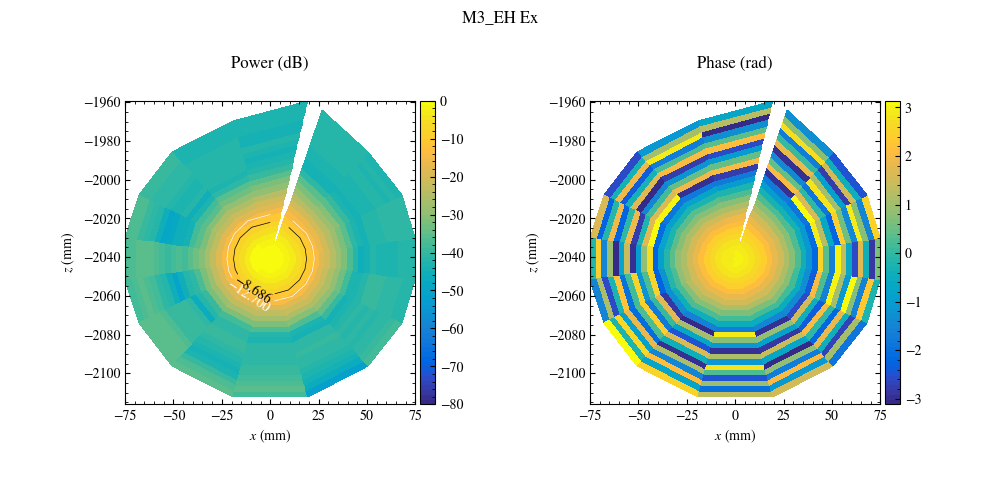

In [18]:
s.plotBeam2D("M3_EH", FieldComponents.Ex, project=Projections.xz, vmin=-80, \
    contour="M3_EH", contour_comp=FieldComponents.Ex, levels=[-12.7, 20*np.log10(np.exp(-1))], \
    correct_phase=[0,0,-1])

## M3 to Secondary Physical Optics

In [19]:
M3_to_Sec_PO = {
    "t_name"    : "secondary",
    "s_current" : "M3_JM",
    "mode"      : "JMEH",
    "name_JM"   : "Sec_JM",
    "name_EH"   : "Sec_EH",
    "device"    : method,
    "nThreads"  : nThreads
}

start = perf_counter()
s.runPO(M3_to_Sec_PO)
step_times.append(perf_counter()-start)

2026-03-17 17:06:39 - WORK - *** Starting PO propagation *** 
2026-03-17 17:06:39 - WORK - Propagating M3_JM on flat_M3 to secondary, propagation mode: JMEH. 
2026-03-17 17:06:39 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-17 17:06:39 - WORK - ... Calculating ... 
2026-03-17 17:06:40 - WORK - *** Finished: 0.372 seconds *** 


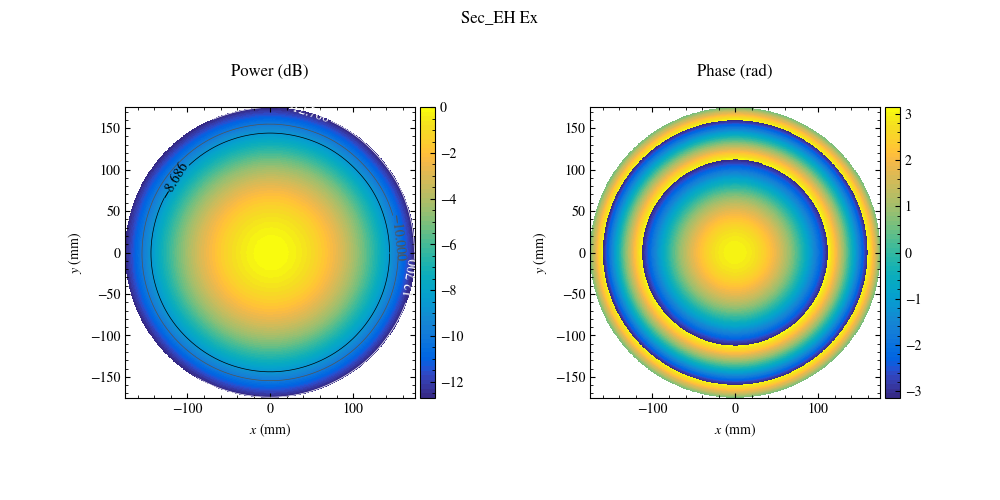

In [20]:
s.plotBeam2D("Sec_EH", FieldComponents.Ex, project=Projections.xy, vmin=-12.7, \
             contour="Sec_EH", contour_comp=FieldComponents.Ex, levels=[-12.7, -10, 20*np.log10(np.exp(-1))], \
             correct_phase=1)

In [21]:
Sec_to_Pri_PO = {
    "t_name"    : "primary",
    "s_current" : "Sec_JM",
    "mode"      : "JMEH",
    "name_JM"   : "Pri_JM",
    "name_EH"   : "Pri_EH",
    "device"    : method,
    "nThreads"  : nThreads
}

start = perf_counter()
s.runPO(Sec_to_Pri_PO)
step_times.append(perf_counter()-start)

2026-03-17 17:06:41 - WORK - *** Starting PO propagation *** 
2026-03-17 17:06:41 - WORK - Propagating Sec_JM on secondary to primary, propagation mode: JMEH. 
2026-03-17 17:06:41 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-17 17:06:41 - WORK - ... Calculating ... 
2026-03-17 17:06:41 - WORK - *** Finished: 0.815 seconds *** 


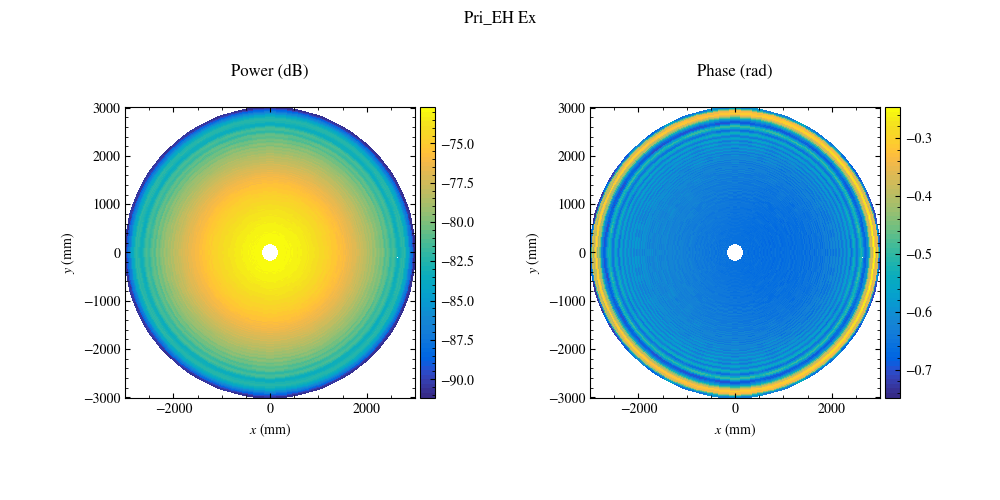

In [22]:
s.plotBeam2D("Pri_EH", FieldComponents.Ex, project=Projections.xy, norm=False, correct_phase=-1)

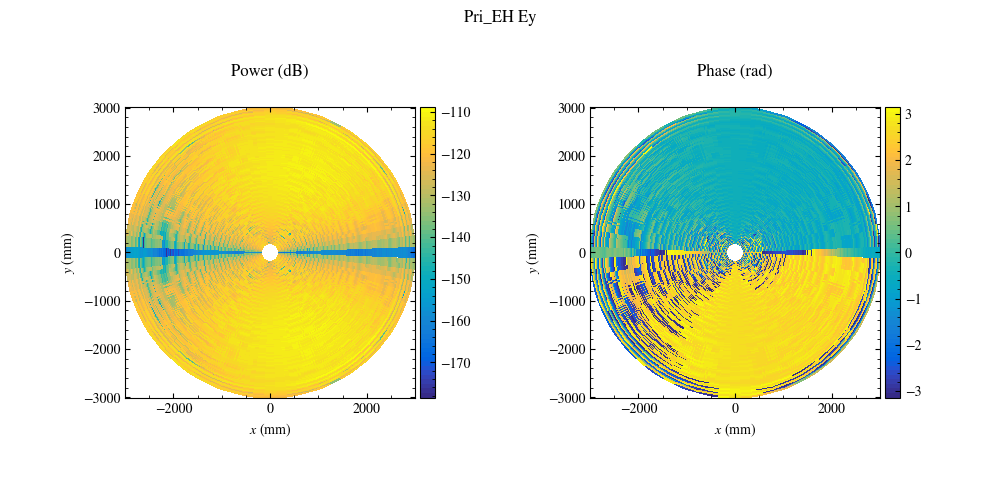

In [23]:
s.plotBeam2D("Pri_EH", FieldComponents.Ey, project=Projections.xy, norm=False, correct_phase=-1)

## Propagate to the far field

In [24]:
plane_ff = {
            "name"      : "plane_ff",
            "gmode"     : "AoE",
            "lims_Az"    : np.array([-1.0, 1.0])*2e-1,
            "lims_El"    : np.array([-1.0, 1.0])*2e-1,
            "gridsize"  : np.array([301, 301])
            }
s.addPlane(plane_ff)

par_to_plane_ff_PO = {
    "t_name"      : "plane_ff",
    "s_current"   : "Pri_JM",
    "mode"        : "FF",
    "name_EH"     : "EH_FF",
    "device"    : method,
    "nThreads"  : nThreads
}

start = perf_counter()
s.runPO(par_to_plane_ff_PO)
step_times.append(perf_counter()-start)

2026-03-17 17:06:42 - INFO - Added plane plane_ff to system. 
2026-03-17 17:06:42 - WORK - *** Starting PO propagation *** 
2026-03-17 17:06:42 - WORK - Propagating Pri_JM on primary to plane_ff, propagation mode: FF. 
2026-03-17 17:06:42 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-17 17:06:42 - WORK - ... Calculating ... 
2026-03-17 17:06:43 - WORK - *** Finished: 0.242 seconds *** 


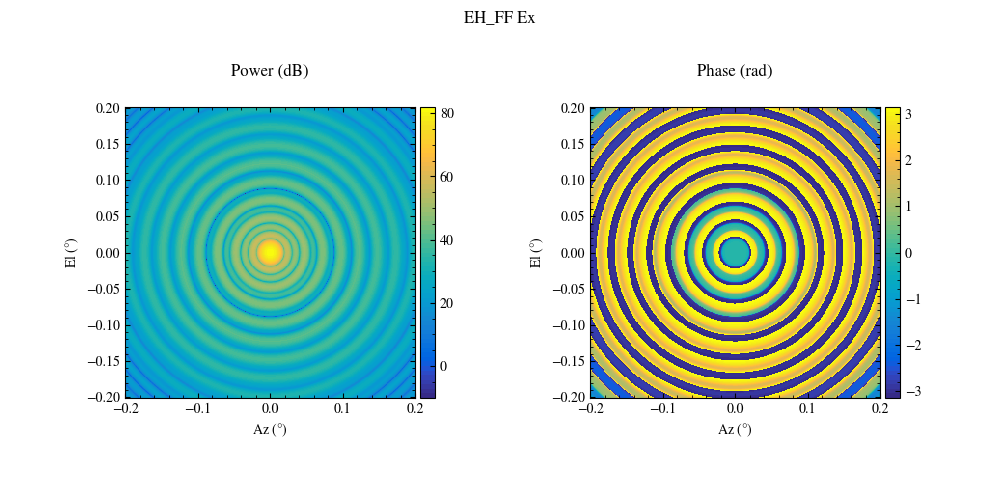

In [25]:
fig, ax = s.plotBeam2D('EH_FF', FieldComponents.Ex,  norm=False, ret=True)

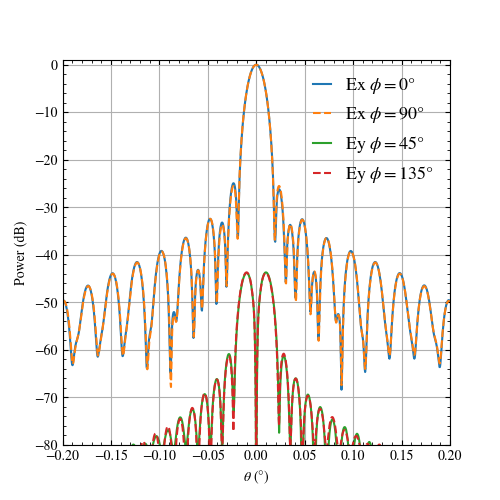

In [26]:
fig, ax = s.plotBeamCut('EH_FF', FieldComponents.Ex, comp_cross=FieldComponents.Ey, phi_cross=45, ret=True, norm=True, vmax=1, vmin=-80)
ax.grid()

In [27]:
step_times

[0.6220290999917779,
 0.16168462099449243,
 0.1583809119911166,
 0.3747356480016606,
 0.8173033810016932,
 0.24565592900034972]